Kaggle data source: https://www.kaggle.com/datasets/zkskhurram/hantavirus-andes-virus-global-epidemiology/data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Phase 1: Creating Database
Read all 10 .csv files and save them to a SQLite database.

In [2]:
#1.
data_dictionary_df = pd.read_csv('data/data_dictionary.csv')
#2.
hv_andes_global_registry_df = pd.read_csv('data/Hantavirus_Andes_Global_Registry.csv')
#3.
hv_clinical_df = pd.read_csv('data/hantavirus_clinical.csv')
#4.
hv_country_yearly_df = pd.read_csv('data/hantavirus_country_yearly.csv')
#5.
hv_environmental_df = pd.read_csv('data/hantavirus_environmental.csv')
#6.
hv_master_df = pd.read_csv('data/hantavirus_master.csv')
#7.
hv_monthly_trends_df = pd.read_csv('data/hantavirus_monthly_trends.csv')
#8.
hv_outbreaks_df = pd.read_csv('data/hantavirus_outbreaks.csv')
#9.
hv_virus_strains_df = pd.read_csv('data/hantavirus_virus_strains.csv')
#10.
sources_metadata_df = pd.read_csv('data/sources_metadata.csv')

In [3]:
import sqlite3

#Connect to database file in project folder
conn = sqlite3.connect('hantavirus.db')

#Save dataframes as SQL tables
data_dictionary_df.to_sql('data_dictionary', conn, if_exists='replace', index=False)
hv_andes_global_registry_df.to_sql('hv_agr', conn, if_exists='replace', index=False)
hv_clinical_df.to_sql('hv_clinical', conn, if_exists='replace', index=False)
hv_country_yearly_df.to_sql('hv_country_yearly', conn, if_exists='replace', index=False)
hv_environmental_df.to_sql('hv_environmental', conn, if_exists='replace', index=False)
hv_master_df.to_sql('hv_master', conn, if_exists='replace', index=False)
hv_monthly_trends_df.to_sql('hv_monthly_trends', conn, if_exists='replace', index=False)
hv_outbreaks_df.to_sql('hv_outbreaks', conn, if_exists='replace', index=False)
hv_virus_strains_df.to_sql('hv_virus_strains', conn, if_exists='replace', index=False)
sources_metadata_df.to_sql('sources_metadata', conn, if_exists='replace', index=False)

print('Database saved!')

Database saved!


# Phase 2: Exploratory Data Analysis & SQL Querying

In [4]:
query1 = """
    SELECT age_group, gender
    FROM hv_clinical
    WHERE severity = 'Critical'
    ORDER BY age_group
"""
critical_cases = pd.read_sql_query(query1, conn)
print(critical_cases)

     age_group  gender
0         0-14  Female
1         0-14  Female
2         0-14  Female
3         0-14  Female
4         0-14  Female
...        ...     ...
1137       60+  Female
1138       60+  Female
1139       60+  Female
1140       60+  Female
1141       60+  Female

[1142 rows x 2 columns]


# Phase 3: Data Visualization

In [5]:
# Global dark theme settings
plt.rcParams.update({
    "figure.facecolor": "#0f0f0f",
    "axes.facecolor": "#1a1a1a",
    "axes.edgecolor": "#444444",
    "axes.labelcolor": "white",
    "text.color": "white",
    "xtick.color": "white",
    "ytick.color": "white",
    "grid.color": "#333333",
    "grid.linestyle": "--",
    "grid.alpha": 0.5,
    "font.family": "sans-serif"
})

print("Style loaded!")

Style loaded!


## Clinical & Outcomes
- What patient demographics (age, sex) are most associated with severe outcomes or death?
- Which virus strains have the highest case fatality rates?
- Do patients with certain symptoms (e.g. respiratory distress) have worse survival rates?

### Chart 1: Distribution of Severity by Age

In [6]:
severity_by_age = """
    SELECT age_group, gender, 
        CASE
            WHEN severity = 'Severe' THEN 2
            WHEN severity = 'Mild' THEN 0
            WHEN severity = 'Moderate' THEN 1
            WHEN severity = 'Critical' THEN 3
            ELSE NULL
        END AS severity_score
    FROM hv_clinical
    ORDER BY age_group, gender
"""

severity_dist = pd.read_sql_query(severity_by_age, conn)

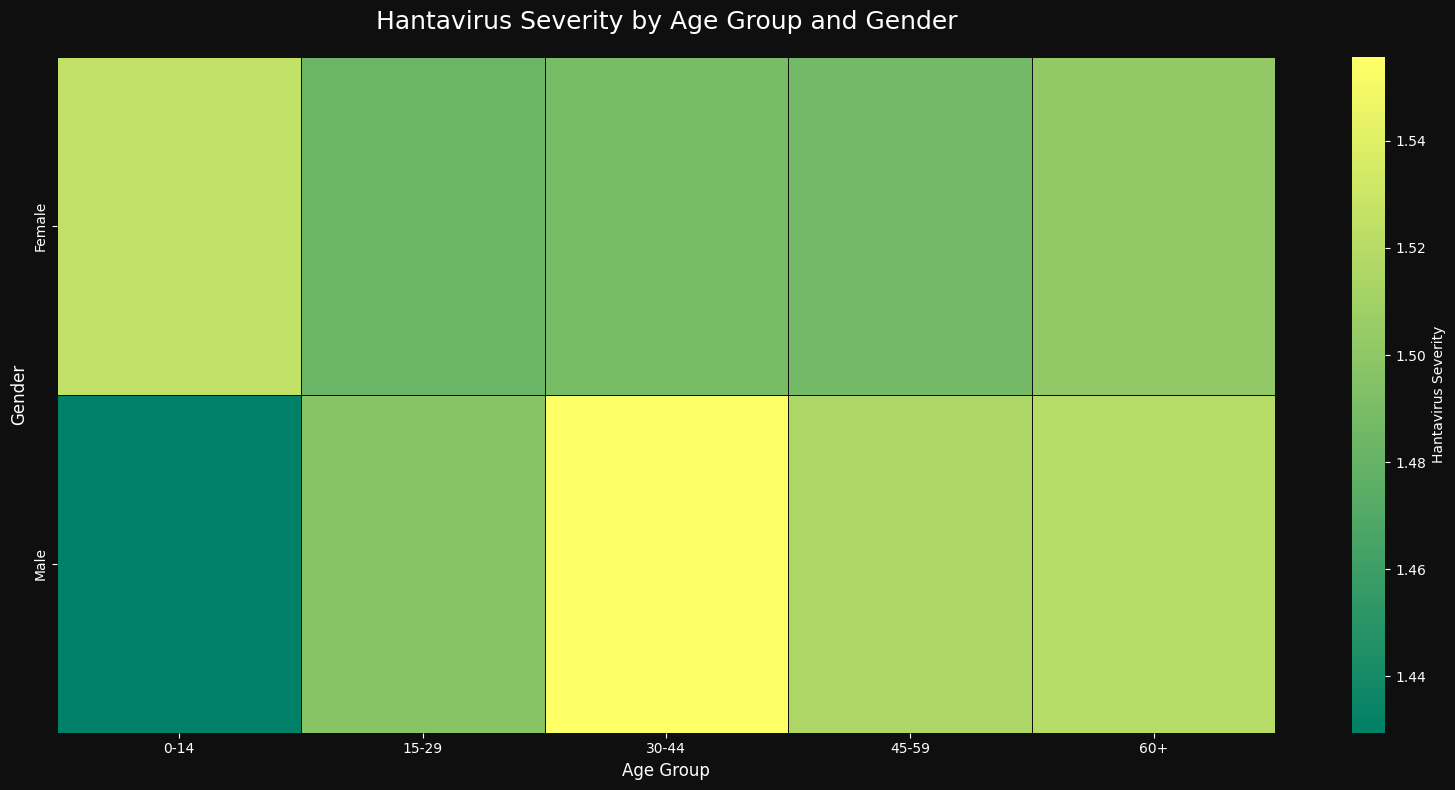

In [7]:
heatmap_pivot = severity_dist.pivot_table(
    index='gender', 
    columns='age_group',
    values='severity_score'
)

fig, ax = plt.subplots(figsize = (16,8))
sns.heatmap(
    heatmap_pivot,
    ax=ax,
    cmap = 'summer',
    linewidth = 0.5, 
    linecolor = '#0f0f0f',
    annot = False,
    cbar_kws={'label': 'Hantavirus Severity'}
)

ax.set_title('Hantavirus Severity by Age Group and Gender', fontsize = 18, pad=20)
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Gender', fontsize=12)

plt.tight_layout()
plt.show()

### Chart 2: Distribution of Fatality Rate by Age & Gender

In [8]:
fatality_by_age = """
    SELECT 
        age_group, 
        gender, 
        SUM(CASE WHEN outcome = 'Recovered' THEN 1 ELSE 0 END) AS recovered,
        SUM(CASE WHEN outcome = 'Deceased' THEN 1 ELSE 0 END) AS deceased
    FROM hv_clinical
    GROUP BY age_group, gender
    ORDER BY age_group, gender
"""

dist_fatality = pd.read_sql_query(fatality_by_age, conn)

dist_fatality['recovery_rate'] = (dist_fatality['recovered'])/(dist_fatality['recovered']+dist_fatality['deceased'])
dist_fatality['deceased_rate'] = 1-dist_fatality['recovery_rate']

dist_fatality

,age_group,gender,recovered,deceased,recovery_rate,deceased_rate
0,0-14,Female,695,126,0.846529,0.153471
1,0-14,Male,610,70,0.897059,0.102941
2,15-29,Female,583,80,0.879336,0.120664
3,15-29,Male,780,98,0.888383,0.111617
4,30-44,Female,677,102,0.869063,0.130937
5,30-44,Male,547,81,0.871019,0.128981
6,45-59,Female,726,120,0.858156,0.141844
7,45-59,Male,679,100,0.871630,0.128370
8,60+,Female,690,85,0.890323,0.109677
9,60+,Male,592,97,0.859216,0.140784


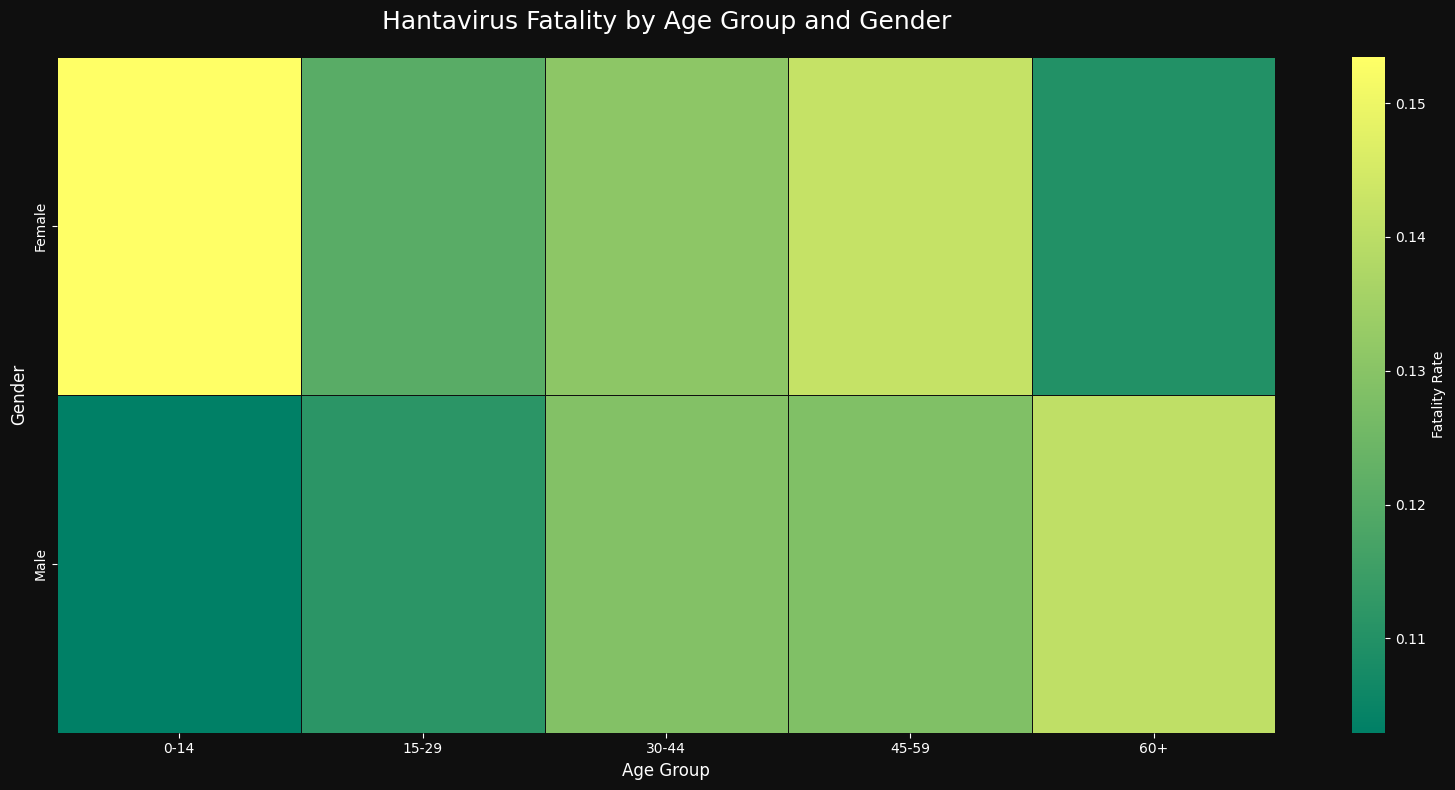

In [9]:
heatmap_pivot2 = dist_fatality.pivot_table(
    index='gender', 
    columns='age_group',
    values='deceased_rate'
)

fig, ax = plt.subplots(figsize = (16,8))
sns.heatmap(
    heatmap_pivot2,
    ax=ax,
    cmap = 'summer',
    linewidth = 0.5, 
    linecolor = '#0f0f0f',
    annot = False,
    cbar_kws={'label': 'Fatality Rate'}
)

ax.set_title('Hantavirus Fatality by Age Group and Gender', fontsize = 18, pad=20)
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Gender', fontsize=12)

plt.tight_layout()
plt.show()

### Chart 3: Distribution of Severity Per Virus Strain

In [10]:
dist_of_severity = """
    SELECT 
        COUNT(severity) AS severity_count, severity, virus_strain
    FROM hv_clinical
    GROUP BY severity, virus_strain
    ORDER BY virus_strain, 
        CASE severity
            WHEN 'Mild' THEN 1
            WHEN 'Moderate' THEN 2
            WHEN 'Severe' THEN 3
            WHEN 'Critical' THEN 4
        END
"""

severity_by_strain = pd.read_sql_query(dist_of_severity, conn)
#severity_by_strain

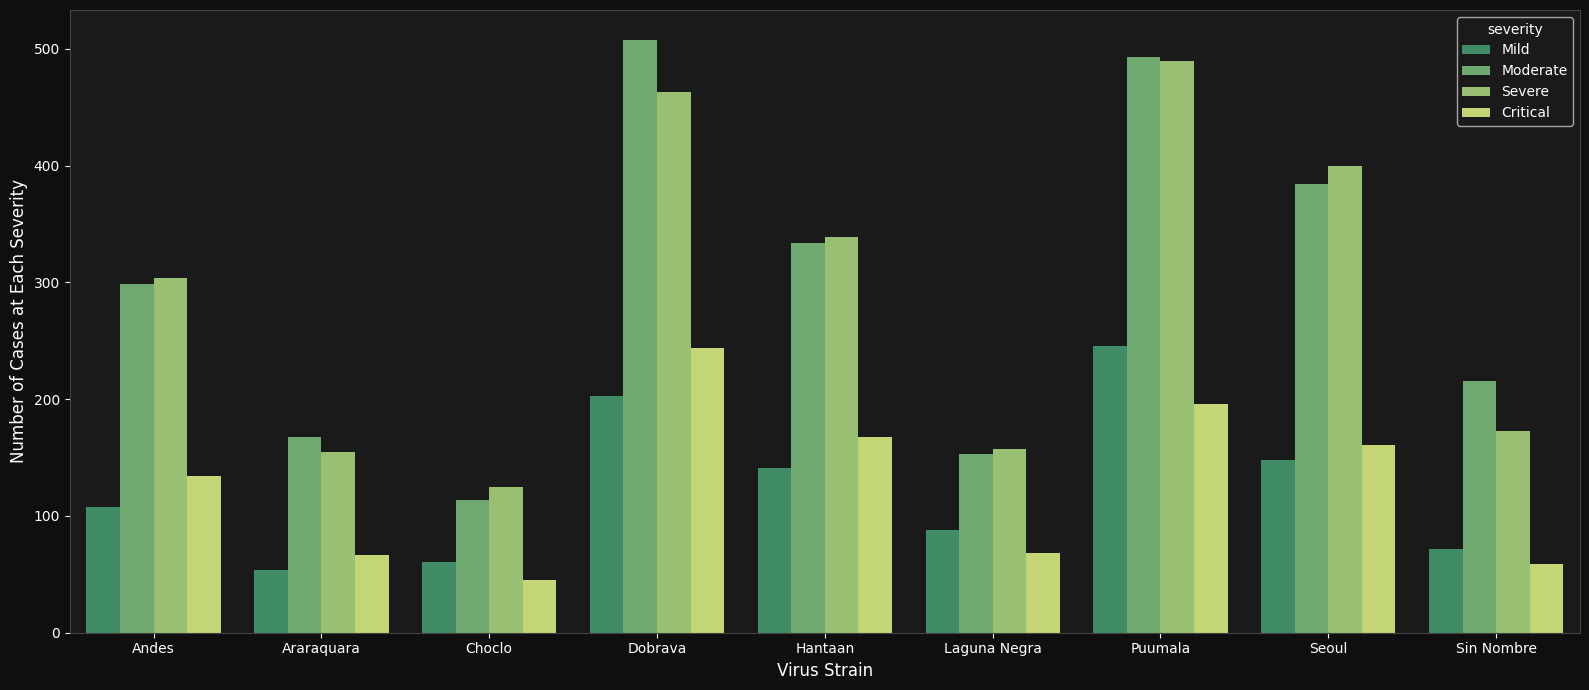

In [11]:
fig, ax = plt.subplots(figsize=(16,7))

sns.barplot(data=severity_by_strain, x='virus_strain', y='severity_count', hue='severity', palette = 'summer')
plt.xlabel('Virus Strain', fontsize=12)
plt.ylabel('Number of Cases at Each Severity', fontsize=12)

plt.tight_layout()
plt.show()

### Chart 4: Fatality Rate Per Virus Strain

In [12]:
dist_of_deceased = """
    SELECT
        virus_strain,
        SUM(CASE WHEN outcome = 'Recovered' THEN 1 ELSE 0 END) AS recovered,
        SUM(CASE WHEN outcome = 'Deceased' THEN 1 ELSE 0 END) AS deceased
    FROM hv_clinical
    GROUP BY virus_strain
    ORDER BY virus_strain
"""

deceased_by_strain = pd.read_sql_query(dist_of_deceased, conn)
deceased_by_strain['recovery_rate'] = (deceased_by_strain['recovered'])/(deceased_by_strain['recovered']+deceased_by_strain['deceased'])
deceased_by_strain['deceased_rate'] = 1-deceased_by_strain['recovery_rate']

deceased_by_strain

,virus_strain,recovered,deceased,recovery_rate,deceased_rate
0,Andes,587,258,0.694675,0.305325
1,Araraquara,304,140,0.684685,0.315315
2,Choclo,264,81,0.765217,0.234783
3,Dobrava,1298,120,0.915374,0.084626
4,Hantaan,920,62,0.936864,0.063136
5,Laguna Negra,343,123,0.736052,0.263948
6,Puumala,1416,9,0.993684,0.006316
7,Seoul,1067,26,0.976212,0.023788
8,Sin Nombre,380,140,0.730769,0.269231


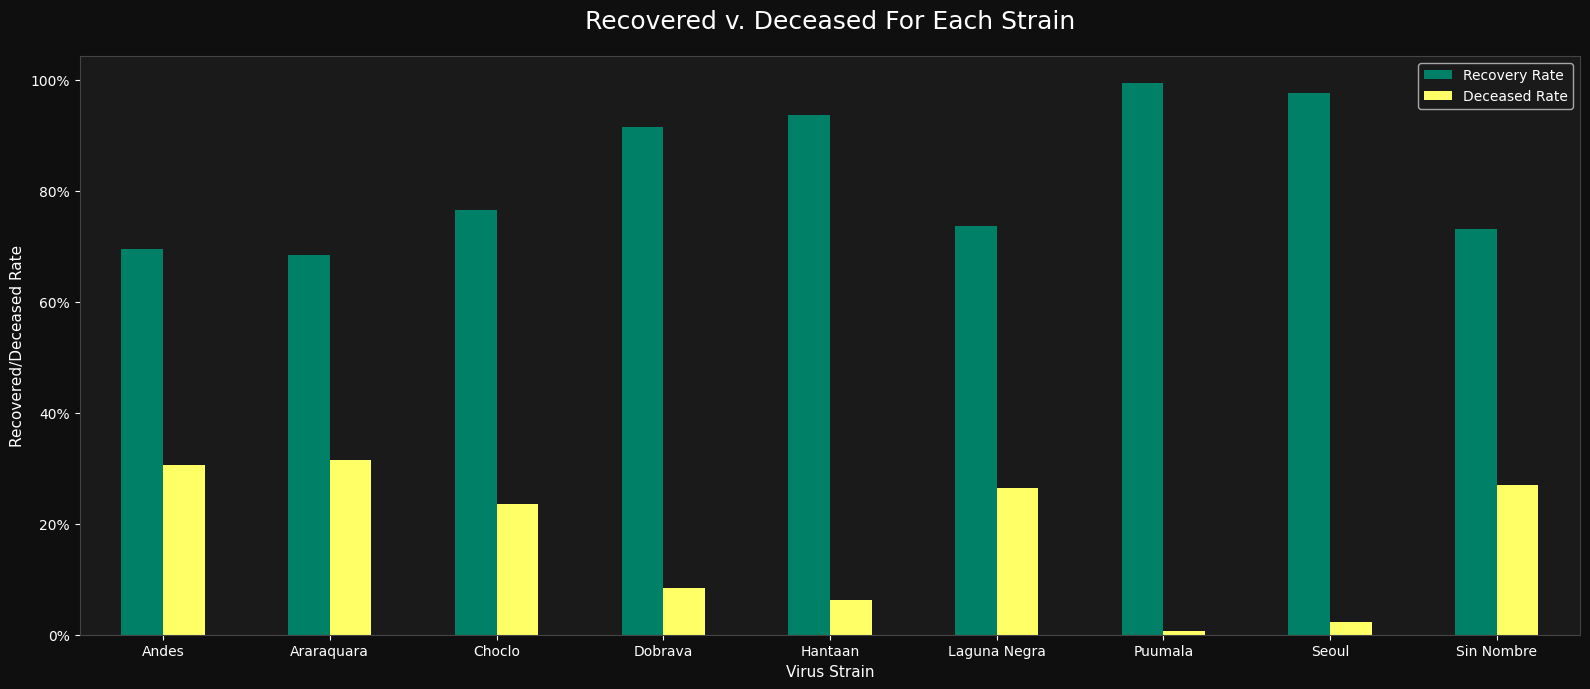

In [13]:
deceased_by_strain.plot(x='virus_strain', y=['recovery_rate', 'deceased_rate'], kind='bar', rot=0, figsize=(16,7), colormap='summer')

plt.title('Recovered v. Deceased For Each Strain', fontsize=18, pad=20)
plt.xlabel('Virus Strain', fontsize=11)
plt.ylabel('Recovered/Deceased Rate', fontsize=11)
plt.legend(['Recovery Rate', 'Deceased Rate'])

plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))

plt.tight_layout()
plt.show()

### Chart 5: Fatality Rate by Symptoms

In [14]:
print(hv_clinical_df.columns.to_list())

['syndrome', 'virus_strain', 'country_iso3', 'age_group', 'gender', 'incubation_days', 'severity', 'hospital_days', 'icu_admission', 'icu_days', 'ventilator_used', 'outcome', 'fever', 'myalgia', 'headache', 'cough', 'dyspnea', 'nausea', 'tachycardia', 'hypotension', 'pulmonary_edema', 'thrombocytopenia', 'back_pain', 'abdominal_pain', 'blurred_vision', 'petechiae', 'oliguria', 'proteinuria', 'hemorrhage']


In [15]:
symptoms = """
    SELECT  
        'Fever' AS symptom,
        fever AS present,
        SUM(CASE WHEN outcome = 'Recovered' THEN 1 ELSE 0 END) AS symptom_recovered,
        SUM(CASE WHEN outcome = 'Deceased' THEN 1 ELSE 0 END) AS symptom_deceased
    FROM hv_clinical
    WHERE fever IS NOT NULL AND present = 1.0
    GROUP BY fever

    UNION ALL

    SELECT 
        'Myalgia' AS symptom, 
        myalgia AS present,
        SUM(CASE WHEN outcome = 'Recovered' THEN 1 ELSE 0 END) AS symptom_recovered,
        SUM(CASE WHEN outcome = 'Deceased' THEN 1 ELSE 0 END) AS symptom_deceased
    FROM hv_clinical
    WHERE myalgia IS NOT NULL AND present = 1.0
    GROUP BY myalgia

    UNION ALL

    SELECT 
        'Headache' AS symptom, 
        headache AS present,
        SUM(CASE WHEN outcome = 'Recovered' THEN 1 ELSE 0 END) AS symptom_recovered,
        SUM(CASE WHEN outcome = 'Deceased' THEN 1 ELSE 0 END) AS symptom_deceased
    FROM hv_clinical
    WHERE headache IS NOT NULL AND present = 1.0
    GROUP BY headache

    UNION ALL

    SELECT 
        'Cough' AS symptom, 
        cough AS present,
        SUM(CASE WHEN outcome = 'Recovered' THEN 1 ELSE 0 END) AS symptom_recovered,
        SUM(CASE WHEN outcome = 'Deceased' THEN 1 ELSE 0 END) AS symptom_deceased
    FROM hv_clinical
    WHERE cough IS NOT NULL AND present = 1.0
    GROUP BY cough

    UNION ALL

    SELECT 
        'Dyspnea' AS symptom, 
        dyspnea AS present,
        SUM(CASE WHEN outcome = 'Recovered' THEN 1 ELSE 0 END) AS symptom_recovered,
        SUM(CASE WHEN outcome = 'Deceased' THEN 1 ELSE 0 END) AS symptom_deceased
    FROM hv_clinical
    WHERE dyspnea IS NOT NULL AND present = 1.0
    GROUP BY dyspnea

    UNION ALL
    
    SELECT 
        'Nausea' AS symptom, 
        nausea AS present,
        SUM(CASE WHEN outcome = 'Recovered' THEN 1 ELSE 0 END) AS symptom_recovered,
        SUM(CASE WHEN outcome = 'Deceased' THEN 1 ELSE 0 END) AS symptom_deceased
    FROM hv_clinical
    WHERE nausea IS NOT NULL AND present = 1.0
    GROUP BY nausea

    UNION ALL
    
    SELECT 
        'Tachycardia' AS symptom, 
        tachycardia AS present,
        SUM(CASE WHEN outcome = 'Recovered' THEN 1 ELSE 0 END) AS symptom_recovered,
        SUM(CASE WHEN outcome = 'Deceased' THEN 1 ELSE 0 END) AS symptom_deceased
    FROM hv_clinical
    WHERE tachycardia IS NOT NULL AND present = 1.0
    GROUP BY tachycardia

    UNION ALL
    
    SELECT 
        'Hypotension' AS symptom, 
        hypotension AS present,
        SUM(CASE WHEN outcome = 'Recovered' THEN 1 ELSE 0 END) AS symptom_recovered,
        SUM(CASE WHEN outcome = 'Deceased' THEN 1 ELSE 0 END) AS symptom_deceased
    FROM hv_clinical
    WHERE hypotension IS NOT NULL AND present = 1.0
    GROUP BY hypotension

    UNION ALL
    
    SELECT 
        'Pulmonary Edema' AS symptom, 
        pulmonary_edema AS present,
        SUM(CASE WHEN outcome = 'Recovered' THEN 1 ELSE 0 END) AS symptom_recovered,
        SUM(CASE WHEN outcome = 'Deceased' THEN 1 ELSE 0 END) AS symptom_deceased
    FROM hv_clinical
    WHERE pulmonary_edema IS NOT NULL AND present = 1.0
    GROUP BY pulmonary_edema

    UNION ALL
    
    SELECT 
        'Thrombocytopenia' AS symptom, 
        thrombocytopenia AS present,
        SUM(CASE WHEN outcome = 'Recovered' THEN 1 ELSE 0 END) AS symptom_recovered,
        SUM(CASE WHEN outcome = 'Deceased' THEN 1 ELSE 0 END) AS symptom_deceased
    FROM hv_clinical
    WHERE thrombocytopenia IS NOT NULL AND present = 1.0
    GROUP BY thrombocytopenia

    UNION ALL
    
    SELECT 
        'Back Pain' AS symptom, 
        back_pain AS present,
        SUM(CASE WHEN outcome = 'Recovered' THEN 1 ELSE 0 END) AS symptom_recovered,
        SUM(CASE WHEN outcome = 'Deceased' THEN 1 ELSE 0 END) AS symptom_deceased
    FROM hv_clinical
    WHERE back_pain IS NOT NULL AND present = 1.0
    GROUP BY back_pain

    UNION ALL
    
    SELECT 
        'Abdominal Pain' AS symptom, 
        abdominal_pain AS present,
        SUM(CASE WHEN outcome = 'Recovered' THEN 1 ELSE 0 END) AS symptom_recovered,
        SUM(CASE WHEN outcome = 'Deceased' THEN 1 ELSE 0 END) AS symptom_deceased
    FROM hv_clinical
    WHERE abdominal_pain IS NOT NULL AND present = 1.0
    GROUP BY abdominal_pain

    UNION ALL
    
    SELECT 
        'Blurred Vision' AS symptom, 
        blurred_vision AS present,
        SUM(CASE WHEN outcome = 'Recovered' THEN 1 ELSE 0 END) AS symptom_recovered,
        SUM(CASE WHEN outcome = 'Deceased' THEN 1 ELSE 0 END) AS symptom_deceased
    FROM hv_clinical
    WHERE blurred_vision IS NOT NULL AND present = 1.0
    GROUP BY blurred_vision

    UNION ALL
    
    SELECT 
        'Petechiae' AS symptom, 
        petechiae AS present,
        SUM(CASE WHEN outcome = 'Recovered' THEN 1 ELSE 0 END) AS symptom_recovered,
        SUM(CASE WHEN outcome = 'Deceased' THEN 1 ELSE 0 END) AS symptom_deceased
    FROM hv_clinical
    WHERE petechiae IS NOT NULL AND present = 1.0
    GROUP BY petechiae

    UNION ALL
    
    SELECT 
        'Oliguria' AS symptom, 
        oliguria AS present,
        SUM(CASE WHEN outcome = 'Recovered' THEN 1 ELSE 0 END) AS symptom_recovered,
        SUM(CASE WHEN outcome = 'Deceased' THEN 1 ELSE 0 END) AS symptom_deceased
    FROM hv_clinical
    WHERE oliguria IS NOT NULL AND present = 1.0
    GROUP BY oliguria

    UNION ALL
    
    SELECT 
        'Proteinuria' AS symptom, 
        proteinuria AS present,
        SUM(CASE WHEN outcome = 'Recovered' THEN 1 ELSE 0 END) AS symptom_recovered,
        SUM(CASE WHEN outcome = 'Deceased' THEN 1 ELSE 0 END) AS symptom_deceased
    FROM hv_clinical
    WHERE proteinuria IS NOT NULL AND present = 1.0
    GROUP BY proteinuria

    UNION ALL
    
    SELECT 
        'Hemorrhage' AS symptom, 
        hemorrhage AS present,
        SUM(CASE WHEN outcome = 'Recovered' THEN 1 ELSE 0 END) AS symptom_recovered,
        SUM(CASE WHEN outcome = 'Deceased' THEN 1 ELSE 0 END) AS symptom_deceased
    FROM hv_clinical
    WHERE hemorrhage IS NOT NULL AND present = 1.0
    GROUP BY hemorrhage
"""

fatality_by_symptoms = pd.read_sql_query(symptoms, conn)

fatality_by_symptoms['symptom_recovery_rate'] = (fatality_by_symptoms['symptom_recovered'])/(fatality_by_symptoms['symptom_recovered']+fatality_by_symptoms['symptom_deceased'])
fatality_by_symptoms['symptom_deceased_rate'] = 1-fatality_by_symptoms['symptom_recovery_rate']

fatality_by_symptoms

,symptom,present,symptom_recovered,symptom_deceased,symptom_recovery_rate,symptom_deceased_rate
0,Fever,1.0,4351,633,0.872994,0.127006
1,Myalgia,1.0,1247,449,0.735259,0.264741
2,Headache,1.0,4217,605,0.874533,0.125467
3,Cough,1.0,1244,491,0.717003,0.282997
4,Dyspnea,1.0,1243,497,0.714368,0.285632
5,Nausea,1.0,4347,616,0.875882,0.124118
6,Tachycardia,1.0,1222,468,0.723077,0.276923
7,Hypotension,1.0,1239,497,0.713710,0.286290
8,Pulmonary Edema,1.0,1215,465,0.723214,0.276786
9,Thrombocytopenia,1.0,1205,476,0.716835,0.283165


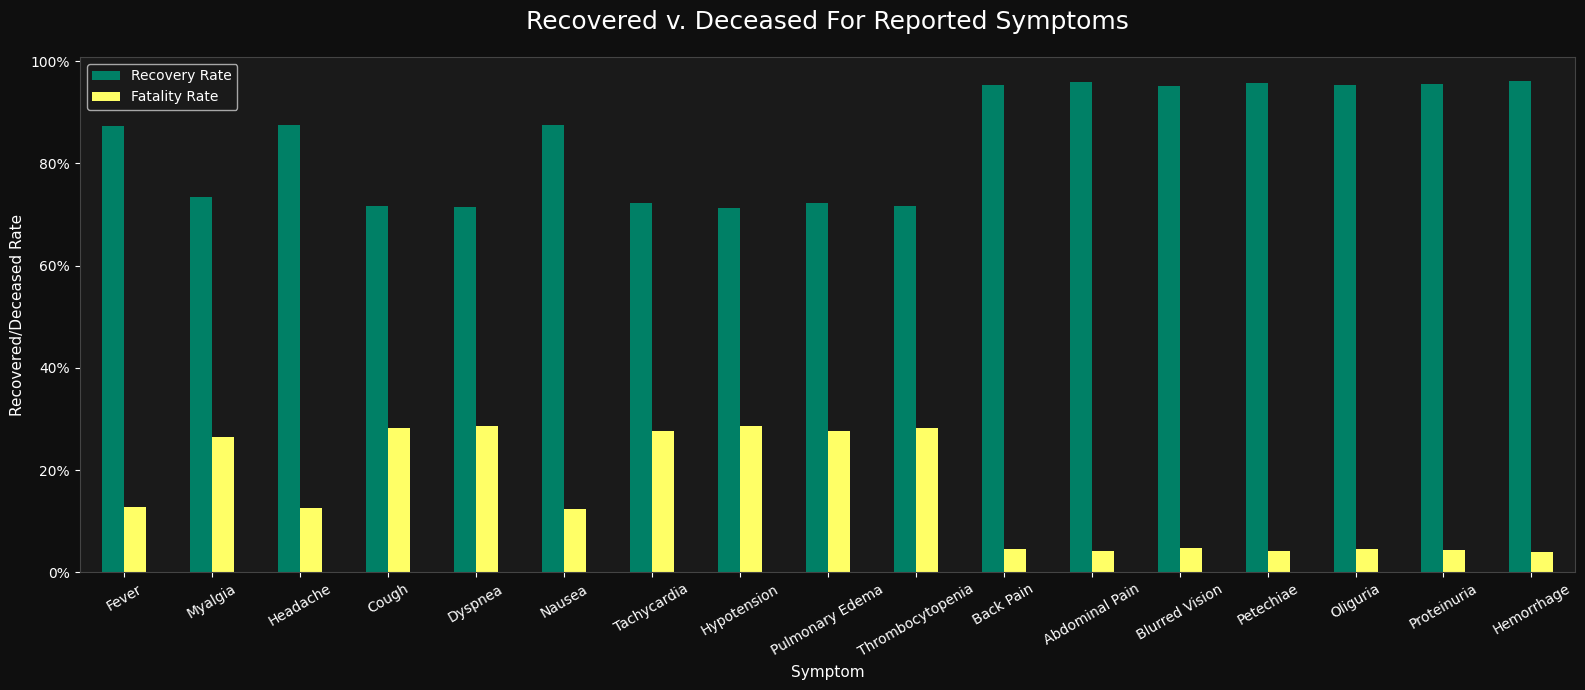

In [16]:
fatality_by_symptoms.plot(x='symptom', y=['symptom_recovery_rate', 'symptom_deceased_rate'], kind='bar', rot=30, figsize=(16,7), colormap='summer')

plt.title('Recovered v. Deceased For Reported Symptoms', fontsize=18, pad=20)
plt.xlabel('Symptom', fontsize=11)
plt.ylabel('Recovered/Deceased Rate', fontsize=11)
plt.legend(['Recovery Rate', 'Fatality Rate'])

plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))

plt.tight_layout()
plt.show()

## Geographic & Country-Level
- Which countries/regions report the most cases, and how has that changed over time?
- Are certain strains geographically concentrated, or do they overlap?
- Which countries have the highest v. lowest case fatality rates? Why might they differ?

In [17]:
tables_query = """
SELECT name
FROM sqlite_master
WHERE type='table'
ORDER BY name
"""

tables = pd.read_sql_query(tables_query, conn)
print(tables)

                name
0    data_dictionary
1             hv_agr
2        hv_clinical
3  hv_country_yearly
4   hv_environmental
5          hv_master
6  hv_monthly_trends
7       hv_outbreaks
8   hv_virus_strains
9   sources_metadata


### Chart 6 & 7: Total Cases Per Country (Top 10) & Yearly Case Trends by Country

In [18]:
print(hv_monthly_trends_df.columns.tolist())

['year', 'month', 'iso3', 'cases', 'deaths']


In [19]:
total_cases_by_country = """
    SELECT 
        country,
        SUM(confirmed_cases) AS total_cases,
        SUM(deaths) AS total_deaths
    FROM hv_country_yearly
    GROUP BY country
    ORDER BY total_cases DESC
    LIMIT 10
"""

total_cases = pd.read_sql_query(total_cases_by_country, conn)

total_cases['fatality_rate'] = total_cases['total_deaths']/total_cases['total_cases']
print(total_cases)

cases_by_country = """
    SELECT 
        year,
        country,
        confirmed_cases
    FROM hv_country_yearly
    WHERE year >= 2015 AND confirmed_cases > 100
    ORDER BY country, year
"""

country_cases = pd.read_sql_query(cases_by_country, conn)
print(country_cases)

       country  total_cases  total_deaths  fatality_rate
0        China      1177156         35685       0.030315
1       Russia       341356         13801       0.040430
2      Finland        81286           741       0.009116
3  South Korea        38537          1905       0.049433
4       Sweden        16014            57       0.003559
5      Germany         5524            42       0.007603
6       France         4229            16       0.003783
7      Belgium         4045            23       0.005686
8    Argentina         2943           842       0.286103
9      Croatia         2280            25       0.010965
    year    country  confirmed_cases
0   2018  Argentina              111
1   2022  Argentina              104
2   2023  Argentina              146
3   2025  Argentina              118
4   2015    Belgium              118
..   ...        ...              ...
82  2021     Sweden              308
83  2022     Sweden              387
84  2023     Sweden              440
85 

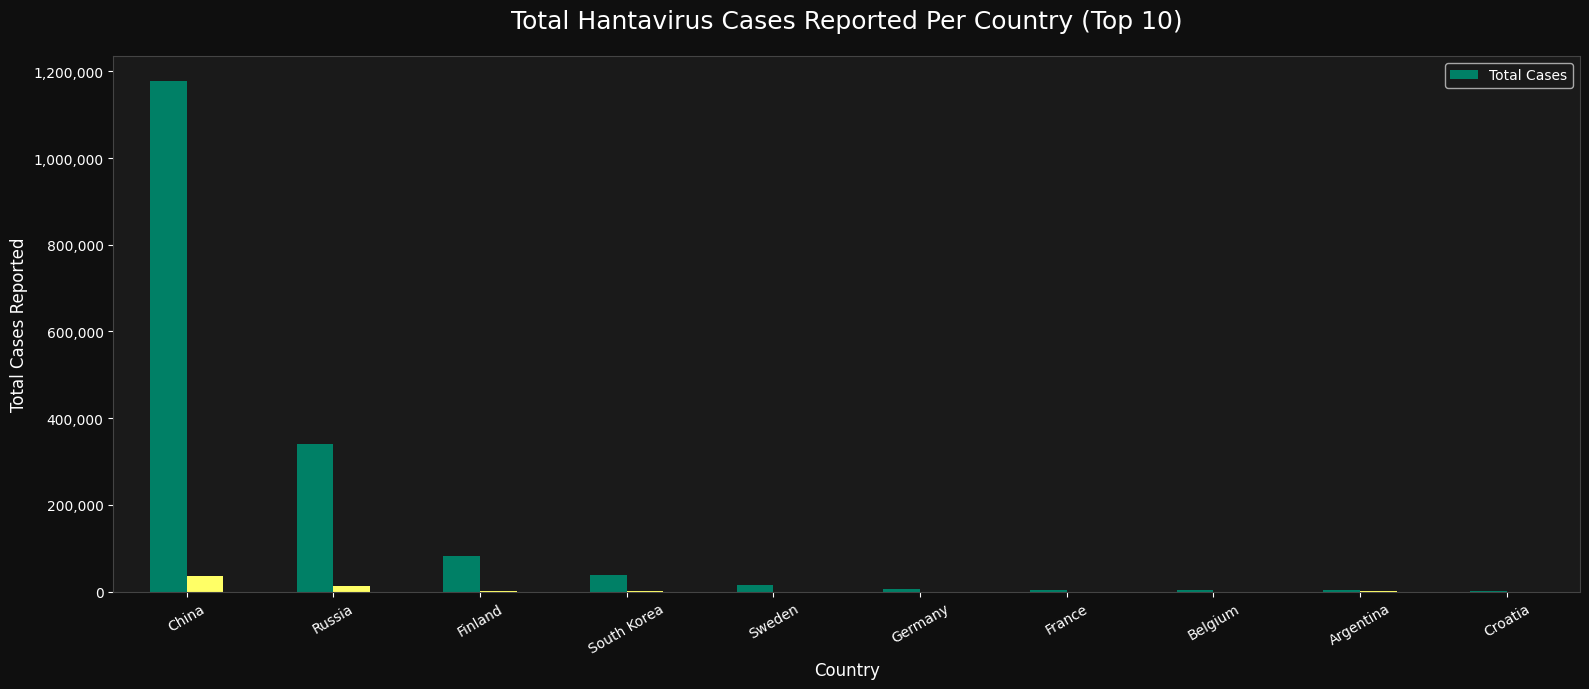

In [20]:
total_cases.plot(x='country', y=['total_cases', 'total_deaths'], kind='bar', rot=30, figsize=(16,7), colormap='summer')

plt.title('Total Hantavirus Cases Reported Per Country (Top 10)', fontsize=18, pad=20)
plt.xlabel('Country', fontsize=12)
plt.ylabel('Total Cases Reported', fontsize=12)
plt.legend(['Total Cases'])

plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.tight_layout()
plt.show()

In [21]:
#ax = sns.barplot(data = total_cases, x='country', y='total_cases', color = 'green')

#plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
#plt.xticks(rotation=45)

#plt.tight_layout()
#plt.show()

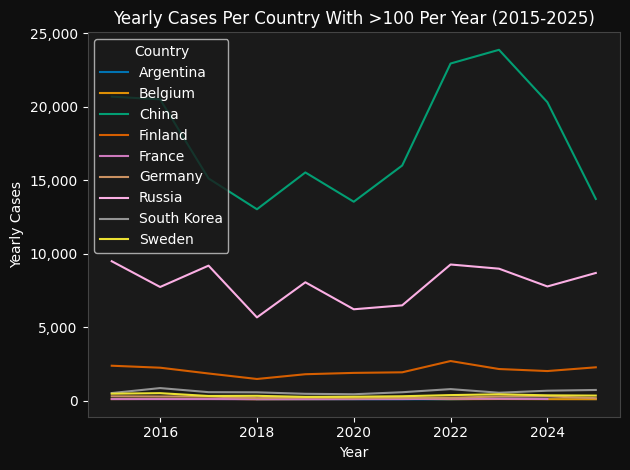

In [22]:
ax = sns.lineplot(data = country_cases, x='year', y='confirmed_cases', hue='country', palette = 'colorblind')

plt.title('Yearly Cases Per Country With >100 Per Year (2015-2025)')
plt.xlabel('Year')
plt.ylabel('Yearly Cases')

legend = plt.gca().get_legend()
legend.set_title('Country')
sns.move_legend(ax, 'upper left')

plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.tight_layout()
plt.show()

### Chart 8: Strains by Region

In [68]:
strains_regions_query = """
    SELECT 
        DISTINCT a.virus_strain AS 'Virus Strain', 
        CASE a.country_iso3
            WHEN 'ARG' THEN 'Argentina'
            WHEN 'CHL' THEN 'Chile'
            WHEN 'BRA' THEN 'Brazil'
            WHEN 'PAN' THEN 'Panama'
            WHEN 'GRC' THEN 'Greece'
            WHEN 'HRV' THEN 'Croatia'
            WHEN 'SVN' THEN 'Slovenia'
            WHEN 'CHN' THEN 'China'
            WHEN 'KOR' THEN 'South Korea'
            WHEN 'PRY' THEN 'Paraguay'
            WHEN 'DEU' THEN 'Germany'
            WHEN 'FIN' THEN 'Finland'
            WHEN 'SWE' THEN 'Sweden'
            WHEN 'USA' THEN 'United States'
            ELSE NULL
        END as country, 
        COUNT(a.virus_strain) AS 'Case Count', b.latitude, b.longitude
    FROM hv_clinical AS a
    JOIN (
        SELECT DISTINCT iso3, latitude, longitude 
        FROM hv_country_yearly
    ) AS b ON a.country_iso3 = b.iso3
    GROUP BY virus_strain, country_iso3
    ORDER BY virus_strain
"""

strains_regions = pd.read_sql_query(strains_regions_query, conn)
strains_regions

,Virus Strain,country,Case Count,latitude,longitude
0,Andes,Argentina,457,-34.6,-58.4
1,Andes,Chile,388,-33.4,-70.7
2,Araraquara,Brazil,444,-15.8,-47.9
3,Choclo,Panama,345,9.0,-79.5
4,Dobrava,Greece,505,37.9,23.7
5,Dobrava,Croatia,439,45.8,16.0
6,Dobrava,Slovenia,474,46.1,14.5
7,Hantaan,China,437,39.9,116.4
8,Hantaan,South Korea,545,37.6,127.0
9,Laguna Negra,Paraguay,466,-25.3,-57.6


In [65]:
import plotly.express as px

In [67]:
# Add small random jitter to separate overlapping points
jitter = 0.8  # adjust this value to spread points more or less
strains_regions['lat_jitter'] = strains_regions['latitude'] + np.random.uniform(-jitter, jitter, len(strains_regions))
strains_regions['lon_jitter'] = strains_regions['longitude'] + np.random.uniform(-jitter, jitter, len(strains_regions))


fig = px.scatter_geo(strains_regions, 
                     lat='lat_jitter', 
                     lon='lon_jitter', 
                     color = 'Virus Strain',
                     size = 'Case Count',
                     hover_name='country',
                     hover_data={'lat_jitter': False, 'lon_jitter': False})

fig.show()

### Chart 9: Highest & Lowest Case Fatality Rates by Region

In [77]:
fatality_rates_by_region_query = """
    SELECT 
        country,
        SUM(confirmed_cases) AS total_cases,
        SUM(deaths) AS total_deaths, 
        (CAST(SUM(deaths) AS FLOAT)/ SUM(confirmed_cases)) AS fatality_rate
    FROM hv_country_yearly
    GROUP BY country
    ORDER BY fatality_rate DESC 
"""

fatality_rates_by_region = pd.read_sql_query(fatality_rates_by_region_query, conn)
fatality_rates_by_region

,country,total_cases,total_deaths,fatality_rate
0,Brazil,1674,601,0.359020
1,Bolivia,358,127,0.354749
2,United States,1089,385,0.353535
3,Chile,1321,419,0.317184
4,Paraguay,306,89,0.290850
5,Argentina,2943,842,0.286103
6,Uruguay,108,21,0.194444
7,Canada,114,22,0.192982
8,Panama,198,36,0.181818
9,South Korea,38537,1905,0.049433


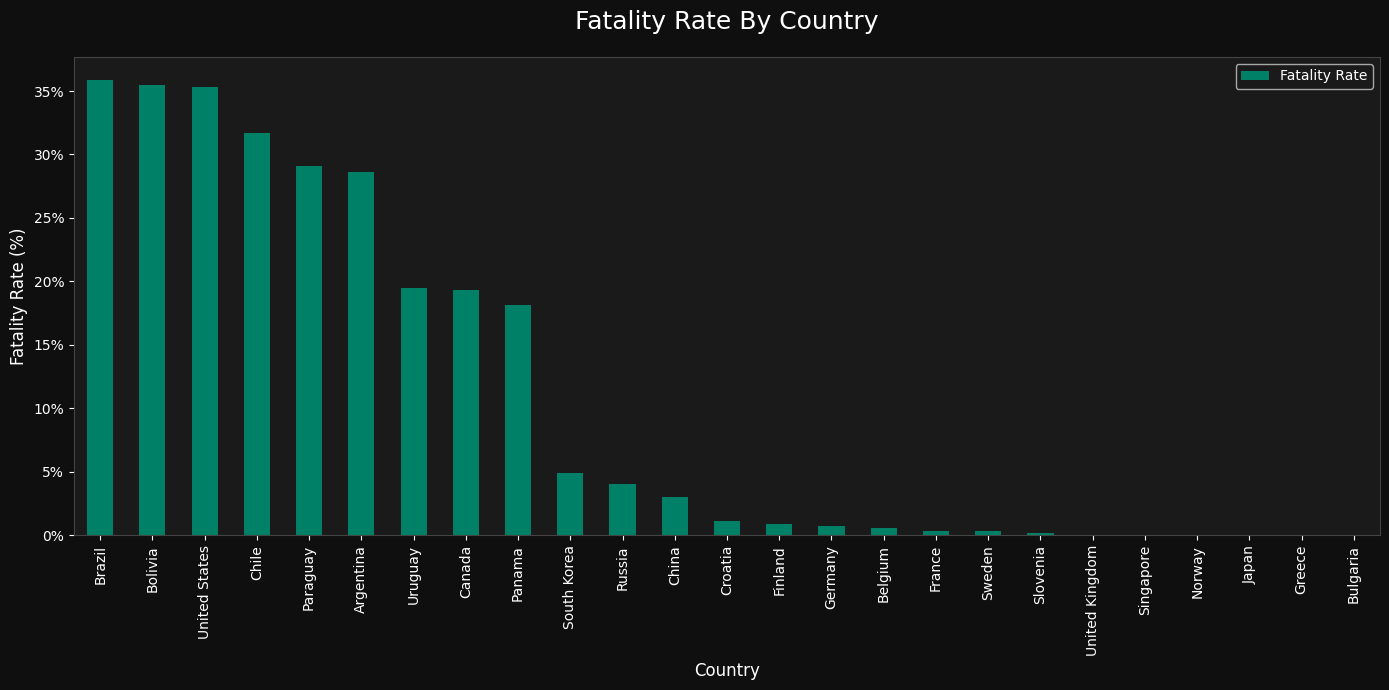

In [83]:
fig = fatality_rates_by_region.plot(kind = 'bar', x='country', y='fatality_rate', figsize=(14,7), colormap = 'summer')

plt.title('Fatality Rate By Country', fontsize=18, pad=20)
plt.xlabel('Country', fontsize=12)
plt.ylabel('Fatality Rate (%)', fontsize=12)
plt.legend(['Fatality Rate'])

plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))

plt.tight_layout()
plt.show()